In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import importlib 
m = importlib.import_module(".model", "src")
em = importlib.import_module(".em", "src")
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np
import xgi
import copy
import random
import statistics
import matplotlib.pyplot as plt
import scipy.special as ss

# Generate a synthetic hypergraph

In [3]:
# generate some sample data

eta   = 0.9   # node retention in edges
gamma = 0.2   # poisson number of nodes from graph
beta  = 0.7   # poisson number of novel nodes

timesteps = int(1e3)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

# Generate some edges in order to perform link prediction

In [4]:

pos_edges = []

for _ in range(int(1e2)):
    temp = H.sample_edge(eta, gamma, beta, True)
    pos_edges.append(temp)
longest = max([len(list(x)) for x in pos_edges])    

In [5]:
neg_edges = []

for _ in range(int(1e2)):
    rand = random.randint(2, longest)
    neg_edges.append(random.sample(range(1, len(H.nodes)), rand))


In [6]:
# estimator likelihood definitions
# pmfs are used in E-step
# m_step estimators are the parameter estimators for each distribution
# used in m-step, using the matrix chi formed in the E-step

# edge sampling
def edge_sample_pmf(x, t, eta):
    return (eta**x)*((1-eta)**(t-x))

def edge_sample_m_step(x, t, chi):
    C = np.tril(chi,-1)
    return (x*C).sum() / (t*C).sum()

esl = em.EdgeSampleLikelihood(
    pmf = edge_sample_pmf, 
    m_step = edge_sample_m_step
    )

# edge sampling: guaranteed version
def guaranteed_edge_sample_pmf(x, t, eta):
    M = (eta**(x-1))*((1-eta)**(t-x)) # ?
    M[x == 0] = 0
    return M

def guaranteed_edge_sample_m_step(x, t, chi):
    C = np.tril(chi,-1)
    top = ((x-1)*C).sum()
    bottom = ((t-1)*C).sum()
    return top / bottom

eslg = em.EdgeSampleLikelihood(
    pmf = guaranteed_edge_sample_pmf, 
    m_step = guaranteed_edge_sample_m_step
    )

# addition of novel nodes not previously seen in the hypergraph
def novel_nodes_pmf(k, beta):
     return (beta**k)*np.exp(beta)/(ss.factorial(k))

def novel_nodes_m_step(k, chi):
    return k.mean()

nnl = em.NovelNodesLikelihood(pmf = novel_nodes_pmf, m_step = novel_nodes_m_step)

# addition of nodes from rest of hypergraph
def nodes_from_hypergraph_pmf(k, gamma):
    return (gamma**k)*np.exp(-gamma)/(ss.factorial(k))

def nodes_from_hypergraph_m_step(x, chi):
    return (np.tril(chi, -1)*x).sum(axis = 1).mean()

nhl = em.NodesFromHypergraphLikelihood(pmf = nodes_from_hypergraph_pmf, m_step = nodes_from_hypergraph_m_step)

In [7]:
# now we build a model using the guaranteed version of the sampler 
# because that's how we built the original hypergraph
model = em.EM(eslg, nhl, nnl) 

# time to fit the model
model.fit(H)

C:\Users\hexie\OneDrive\Desktop\Projects\hypergraph\HyperGraph\code\src\em.py:121: RuntimeWarning: divide by zero encountered in log
  return np.ma.masked_invalid(np.log(means)).sum()


In [8]:
# compare pars to original
model.pars

{'eta': 0.889600556195755,
 'beta': 0.690562613430127,
 'gamma': 0.21453136732997163}

In [14]:
to_pred = [list(x) for x in pos_edges] + [list(x) for x in neg_edges]
true_label = [1]*int(1e2) + [0]*int(1e2)
PRED = model.predict(to_pred)
threshold = statistics.median(PRED)
pred_label = copy.deepcopy(PRED)
pred_label[pred_label>threshold] = 1
pred_label[pred_label<=threshold] = 0

In [15]:
PRED

array([0.0008628 , 0.00154859, 0.00413293, 0.00122554, 0.00086282,
       0.00174132, 0.00782796, 0.00309721, 0.0027256 , 0.00122554,
       0.00232289, 0.0012258 , 0.00232327, 0.00232289, 0.00183833,
       0.00174108, 0.00183831, 0.00122554, 0.00195738, 0.00154878,
       0.00609279, 0.00096989, 0.00542007, 0.00122554, 0.00137775,
       0.00306389, 0.00154859, 0.00086283, 0.00109037, 0.00109024,
       0.0066177 , 0.00391918, 0.00196242, 0.00122554, 0.00096988,
       0.0017408 , 0.00154867, 0.00294612, 0.00154873, 0.00154862,
       0.00782933, 0.00137765, 0.00137768, 0.00309718, 0.02935699,
       0.00163551, 0.00122556, 0.00978452, 0.00174077, 0.00174077,
       0.00195704, 0.00068281, 0.01565941, 0.00174083, 0.00391381,
       0.00154865, 0.00206647, 0.00154859, 0.0034827 , 0.00154859,
       0.00163536, 0.00551058, 0.00137763, 0.0017408 , 0.00551088,
       0.00174077, 0.00137765, 0.00206685, 0.00309718, 0.00154862,
       0.00137768, 0.00782926, 0.0010903 , 0.00122567, 0.00272

In [16]:
def plot_AUC(y_pred, y_true):
    
    fpr, tpr, _ = roc_curve(y_true,y_pred)
    roc_auc = auc(fpr, tpr)
    plt.clf()
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve for random forest')
    plt.legend(loc="lower right")
    plt.show()

def plot_PR(y_pred, y_true):

    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    plt.plot(recall, precision, marker='.', label='PR curve')
    # axis labels
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    # show the legend
    plt.legend()
    plt.title('Precision Recall curve for unipartite host networks')
    plt.savefig("Host-unipartite-PR.pdf", bbox_inches='tight')



<Figure size 640x480 with 0 Axes>

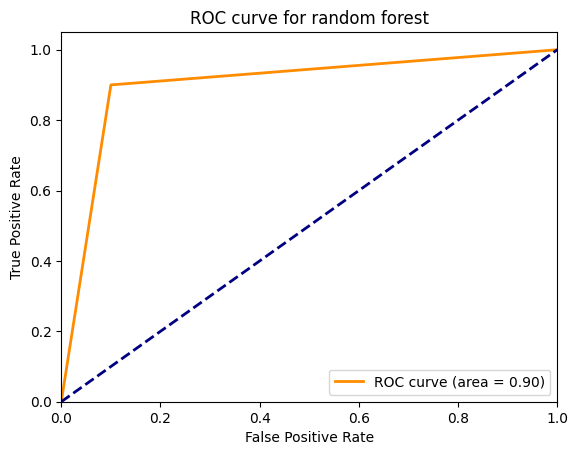

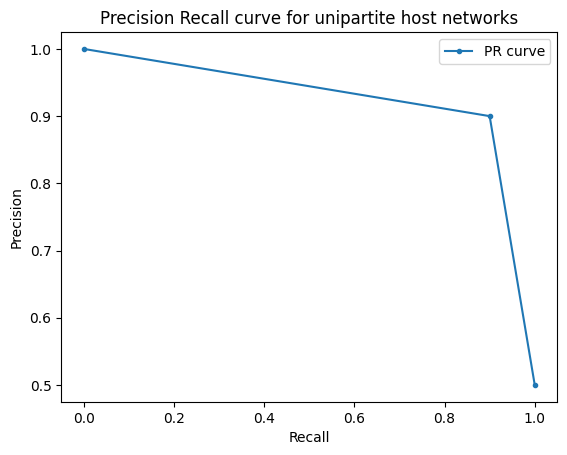

In [17]:
plot_AUC(pred_label, true_label)

plot_PR(pred_label, true_label)
